##### Copyright 2026 Google LLC.

In [1]:
# @title Licensed under the Apache License, Version 2.0 (the "License");
#
# Licensed under the Apache License, Version 2.0 (the "License");
# you may not use this file except in compliance with the License.
# You may obtain a copy of the License at
#
#     https://www.apache.org/licenses/LICENSE-2.0
#
# Unless required by applicable law or agreed to in writing, software
# distributed under the License is distributed on an "AS IS" BASIS,
# WITHOUT WARRANTIES OR CONDITIONS OF ANY KIND, either express or implied.
# See the License for the specific language governing permissions and
# limitations under the License.

# Gemini API: Getting started with Gemini models

<a target="_blank" href="https://colab.research.google.com/github/google-gemini/cookbook/blob/main/quickstarts/Get_started.ipynb"><img src="https://colab.research.google.com/assets/colab-badge.svg" height=30/></a>

The **[Google Gen AI SDK](https://github.com/googleapis/python-genai)** provides a unified interface to [Gemini models](https://ai.google.dev/gemini-api/docs/models) through both the [Gemini Developer API](https://ai.google.dev/gemini-api/docs) and the Gemini API on [Vertex AI](https://cloud.google.com/vertex-ai/generative-ai/docs/overview). With a few exceptions, code that runs on one platform will run on both. This notebook uses the Developer API.

This notebook will walk you through:

* [Installing and setting-up](#setup) the Google GenAI SDK
* [Text](#text_prompt) and [multimodal](#multimodal_prompt) prompting
* Setting [system instructions](#system_instructions)
* Controlling the [thinking](#thinking) process, including [thinking levels](#thinking) and [thought signatures](#thought_signatures)
* Counting [tokens](#count_tokens)
* Configuring [model parameters](#parameters)
* [Generating images](#image_gen)
* [Safety filters](#safety_filters)
* Initiating a [multi-turn chat](#chat) and [saving/resuming conversations](#chat)
* Generating a [content stream](#stream) and sending [asynchronous](#async) requests
* [Controlling generated output](#json) (JSON mode)
* Using [function calling](#function_calling)
* [Uploading files](#file_api) (text, images, PDFs, audio, video)
* [Media resolution](#media_resolution) control
* Grounding with [Google Search](#grounding), [Google Maps](#maps), [YouTube](#youtube_link) or [URLs](#url_context)
* Using [code execution](#code_execution)
* [Context caching](#caching)
* Generating [embeddings](#embeddings)
* [Migrating from Gemini 2.5](#gemini3migration)

More details about the SDK on the [documentation](https://ai.google.dev/gemini-api/docs/sdks).

> **Note:** This notebook uses the [Interactions API](https://ai.google.dev/gemini-api/docs/interactions), the latest way to interact with Gemini models. The Interactions API provides built-in conversation state management, making multi-turn conversations simpler — just pass a `previous_interaction_id` instead of managing chat history yourself.
>
> Looking for the `generateContent` version? Check the [Get started with Generate Content](./Get_started_Generate_Content.ipynb) notebook.

Feature-specific models have their own dedicated guides:
* Podcast and speech generation using [Gemini TTS ![image](https://storage.googleapis.com/generativeai-downloads/images/colab_icon16.png)](./Get_started_TTS.ipynb),
* Live interaction with [Gemini Live ![image](https://storage.googleapis.com/generativeai-downloads/images/colab_icon16.png)](./Get_started_LiveAPI.ipynb),
* Image generation using [Imagen ![image](https://storage.googleapis.com/generativeai-downloads/images/colab_icon16.png)](./Get_started_imagen.ipynb),
* Video generation using [Veo ![image](https://storage.googleapis.com/generativeai-downloads/images/colab_icon16.png)](./Get_started_Veo.ipynb),
* Music generation using [Lyria RealTime ![image](https://storage.googleapis.com/generativeai-downloads/images/colab_icon16.png)](./Get_started_LyriaRealTime.ipynb).

<a name="setup"></a>
## Setup

### Install SDK

Install the SDK from [PyPI](https://github.com/googleapis/python-genai). It's recommended to always use the latest version.

### Setup your API key

To run the following cell, your API key must be stored in a Colab Secret named `GEMINI_API_KEY`. If you don't already have an API key or you aren't sure how to create a Colab Secret, see [Authentication ![image](https://storage.googleapis.com/generativeai-downloads/images/colab_icon16.png)](../quickstarts/Authentication.ipynb) for a walkthrough.

In [2]:
import os
try:
    from google.colab import userdata
    GEMINI_API_KEY = userdata.get('GEMINI_API_KEY')
except ImportError:
    GEMINI_API_KEY = os.environ.get('GEMINI_API_KEY')
from google import genai
client = genai.Client(api_key=GEMINI_API_KEY)


### Initialize SDK client

With the new SDK, now you only need to initialize a client with your API key (or OAuth if using [Vertex AI](https://cloud.google.com/vertex-ai)). The model is now set in each call.

In [3]:
import sys
print("Python executable:", sys.executable)
print("Python path:", sys.path)

Python executable: /usr/local/google/home/giom/.gemini/jetski/scratch/venv/bin/python
Python path: ['/usr/local/buildtools/current/sitecustomize', '/usr/lib/python313.zip', '/usr/lib/python3.13', '/usr/lib/python3.13/lib-dynload', '', '/usr/local/google/home/giom/.gemini/jetski/scratch/venv/lib/python3.13/site-packages']


In [4]:
from google import genai
from google.genai import types

client = genai.Client(api_key=GEMINI_API_KEY)

Select the model you want to use in this guide:

In [5]:
MODEL_ID = "gemini-3-flash-preview" # @param ["gemini-3.1-flash-lite", "gemini-3-flash-preview", "gemini-3.1-pro-preview"] {"allow-input":true, isTemplate: true}

<a name="text_prompt"></a>
## Send text prompts

Use the `interactions.create` method to generate responses from text-only input.

In [6]:
from IPython.display import Markdown

interaction = client.interactions.create(
    model=MODEL_ID,
    input="Explain how AI works in a few words",
)

# The response is an Interaction object containing a list of steps.
# Each step represents a part of the model's response.
# Let's look at what the steps contain:
print(f"Number of steps: {len(interaction.steps)}")
for j, step in enumerate(interaction.steps):
    print(f"  Step {j}: type={step.type}")

RateLimitError: Error code: 429 - {'error': {'message': 'You do not have enough quota to make this request.', 'code': 'too_many_requests'}}

The last step (index `-1`) contains the model's text output. Access the text via `.content[0].text`:

In [7]:
# Access the text response:
Markdown(interaction.steps[-1].content[0].text)

NameError: name 'interaction' is not defined

<a name="system_instructions"></a>
## Add system instructions

You can also add system instructions to steer the behavior of the model. Note that system instructions will be set for the whole interaction and not per turn.

In [8]:
system_instruction = "You are a pirate and are explaining things to 5 years old kids."

interaction = client.interactions.create(
    model=MODEL_ID,
    input="Explain how AI works",
    system_instruction=system_instruction,
)

Markdown(interaction.steps[-1].content[0].text)

RateLimitError: Error code: 429 - {'error': {'message': 'You do not have enough quota to make this request.', 'code': 'too_many_requests'}}

<a name="count_tokens"></a>
## Count tokens

Tokens are the basic inputs to the Gemini models. You can use the `count_tokens` method to calculate the number of input tokens before sending a request to the Gemini API.

In [9]:
response = client.models.count_tokens(
    model=MODEL_ID,
    contents="What's the highest mountain in Africa?",
)

print(f"This prompt was worth {response.total_tokens} tokens.")

This prompt was worth 10 tokens.


<a name="parameters"></a>
## Configure model parameters

You can include parameter values in each call you send to a model using `generation_config`.

In [10]:
interaction = client.interactions.create(
    model=MODEL_ID,
    input="Tell me how the internet works, but pretend I'm a puppy who understands only dog-related analogies.",
    generation_config={
        "temperature": 2,
        "top_p": 0.5,
        "max_output_tokens": 500,
    },
)

Markdown(interaction.steps[-1].content[0].text)

RateLimitError: Error code: 429 - {'error': {'message': 'You do not have enough quota to make this request.', 'code': 'too_many_requests'}}

<a name="thinking"></a>
## Control the thinking process

Gemini models support configurable **thinking levels** that control how much internal reasoning the model performs before responding. Higher thinking levels produce better results for complex tasks but use more tokens and take longer.

Available thinking levels: `"minimal"`, `"low"`, `"medium"`, `"high"`

See [Get started with thinking](./Get_started_thinking.ipynb) for a complete guide.


In [11]:
from IPython.display import display, Markdown

thinking_level = "low" # @param ["minimal", "low", "medium", "high"]

interaction = client.interactions.create(
    model=MODEL_ID,
    input="A man moves his car to a hotel and tells the owner he's bankrupt. Why?",
    generation_config={"thinking_level": thinking_level},
)

# Display the thinking process and the answer
for step in interaction.steps:
    if step.type == "thought":
        print("💭 Thought:", getattr(step, "text", "")[:200] if hasattr(step, "text") else "(thinking...)")
    elif step.type == "model_output" and step.content:
        display(Markdown(step.content[0].text))


RateLimitError: Error code: 429 - {'error': {'message': 'You do not have enough quota to make this request.', 'code': 'too_many_requests'}}

<a name="thought_signatures"></a>
### Thought signatures

Gemini models include a `thought_signature` in responses. This is managed automatically by the SDK, but here's what happens behind the scenes:

In [12]:
# Create an interaction with thinking enabled to get a thought signature
interaction_with_thinking = client.interactions.create(
    model=MODEL_ID,
    input="What is 15! (15 factorial)?",
)

# Print the thought signature from the response
for step in interaction_with_thinking.steps:
    if step.type == "thought" and hasattr(step, 'signature') and step.signature:
        print(f"Thought signature: {step.signature[:100]}...")
        break
else:
    print("No thought signature found in this response.")


RateLimitError: Error code: 429 - {'error': {'message': 'You do not have enough quota to make this request.', 'code': 'too_many_requests'}}

The signature helps the model remember not only what was said before, but also what it *thought* before and what it got from tools and function calls.

For example: if you ask for today's temperature, the model might use Google Search and learn it's 25°C *and* that humidity is 60%. If you then ask about humidity, it can recall this from the first call without making a new request.

More details on [thought signatures](https://ai.google.dev/gemini-api/docs/gemini-3?thinking=explicit#thought_signatures) in the documentation.

<a name="multimodal_prompt"></a>
## Send multimodal prompts

Use Gemini model, a multimodal model that supports multimodal prompts. You can include text, [PDF documents ![image](https://storage.googleapis.com/generativeai-downloads/images/colab_icon16.png)](../quickstarts/PDF_Files.ipynb), images, [audio ![image](https://storage.googleapis.com/generativeai-downloads/images/colab_icon16.png)](../quickstarts/Audio.ipynb) and [videos ![image](https://storage.googleapis.com/generativeai-downloads/images/colab_icon16.png)](../quickstarts/Video.ipynb) in your prompt requests and get text or code responses. Check the [File API](#file_api) section below for more examples.

In this first example, you'll download an image from a specified URL, save it as a byte stream and then write those bytes to a local file named `jetpack.png`.

The simplest way is to pass an image URL directly in your prompt:

In [13]:
from IPython.display import display, Markdown

interaction = client.interactions.create(
    model=MODEL_ID,
    input=[
        {
            "type": "image",
            "uri": "https://storage.googleapis.com/generativeai-downloads/images/generated_elephants_giraffes_zebras_sunset.jpg",
        },
        {"type": "text", "text": "What do you see in this image? Describe it briefly."},
    ],
)

display(Markdown(interaction.steps[-1].content[0].text))

RateLimitError: Error code: 429 - {'error': {'message': 'You do not have enough quota to make this request.', 'code': 'too_many_requests'}}

You can also download an image and send it as base64-encoded data. This is useful when you need to preprocess the image or when the URL is not publicly accessible:

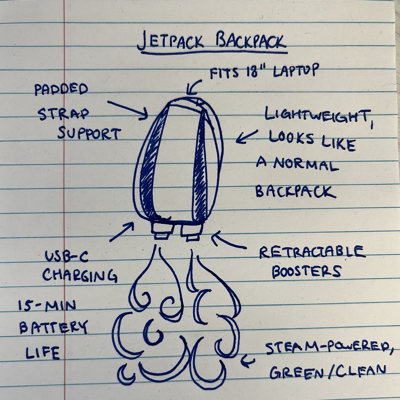

In [14]:
import requests
import pathlib
from PIL import Image
from IPython.display import display

IMG = "https://storage.googleapis.com/generativeai-downloads/data/jetpack.png" # @param {type: "string"}

img_bytes = requests.get(IMG).content

img_path = pathlib.Path('jetpack.png')
img_path.write_bytes(img_bytes)

# Display the image
display(Image.open(img_path).resize((400, 400)))

In [15]:
import base64
from IPython.display import display, Markdown

# Encode the image as base64 to send it inline with the prompt
img_b64 = base64.b64encode(img_path.read_bytes()).decode("utf-8")

interaction = client.interactions.create(
    model=MODEL_ID,
    input=[
        {"type": "image", "data": img_b64, "mime_type": "image/png"},
        {"type": "text", "text": "Write a short and engaging blog post based on this picture."},
    ],
)

display(Markdown(interaction.steps[-1].content[0].text))

RateLimitError: Error code: 429 - {'error': {'message': 'You do not have enough quota to make this request.', 'code': 'too_many_requests'}}

<a name="image_gen"></a>
## Generate images

Gemini models can also generate images as part of their response. Use `response_format` to request both text and image outputs. You need to use a model that supports image generation (like `gemini-3.1-flash-image-preview`).


In [16]:
from IPython.display import Image, Markdown, display
import base64

interaction = client.interactions.create(
    model="gemini-3.1-flash-image-preview",
    input="Generate an image of a cat wearing a top hat in a library.",
    response_format=[{"type": "text"}, {"type": "image", "mime_type": "image/jpeg", "delivery": "inline"}],
)

# Display all content from model output steps
for step in interaction.steps:
    if step.type == "model_output":
        for content in step.content:
            if content.type == "image" and hasattr(content, 'data') and content.data:
                display(Image(data=base64.b64decode(content.data), format="jpeg"))
            elif content.type == "text" and content.text:
                display(Markdown(content.text))

BadRequestError: Error code: 400 - {'error': {'message': 'Image delivery mode is not supported.', 'code': 'invalid_request'}}

<a name="safety_filters"></a>
## Safety filters

Gemini models have built-in safety filters that are always active. The models manage safety automatically — there are no configurable safety settings to set. For more details, see the [safety documentation](https://ai.google.dev/gemini-api/docs/safety-settings).

<a name="chat"></a>
## Start a multi-turn conversation

The Interactions API enables multi-turn conversations using `previous_interaction_id` to chain interactions. The server manages conversation state — you just pass the ID from the previous turn.

In [17]:
from IPython.display import Markdown

# First turn: ask a question
turn_1 = client.interactions.create(
    model=MODEL_ID,
    input="Why do we always see the same side of the Moon? Keep it short.",
)

Markdown(turn_1.steps[-1].content[0].text)


RateLimitError: Error code: 429 - {'error': {'message': 'You do not have enough quota to make this request.', 'code': 'too_many_requests'}}

Use `previous_interaction_id` to send follow-up messages. The model remembers the full conversation context.

In [18]:
# Follow-up question referencing the previous answer
turn_2 = client.interactions.create(
    model=MODEL_ID,
    input="Interesting! Has any human or spacecraft actually seen the far side?",
    previous_interaction_id=turn_1.id,
)

Markdown(turn_2.steps[-1].content[0].text)


NameError: name 'turn_1' is not defined

### Switch models mid-conversation

One powerful feature of the Interactions API is that you can **switch models within the same conversation**. Here, we switch to an image generation model to create a visual inspired by the conversation:


In [19]:
IMAGE_MODEL = "gemini-3.1-flash-image-preview" # @param ["gemini-3.1-flash-image-preview"] {"allow-input":true, isTemplate: true}

# Continue the same conversation with an image generation model
turn_3 = client.interactions.create(
    model=IMAGE_MODEL,
    input="Based on what we discussed, generate an image of the far side of the Moon as seen from a spacecraft.",
    previous_interaction_id=turn_2.id,
    response_format=[{"type": "text"}, {"type": "image", "mime_type": "image/jpeg", "delivery": "inline"}],
)

from IPython.display import Image, display
import base64

for step in turn_3.steps:
    if step.type == "model_output":
        for content in step.content:
            if content.type == "image" and hasattr(content, "data") and content.data:
                display(Image(data=base64.b64decode(content.data), format="jpeg"))
            elif content.type == "text" and content.text:
                display(Markdown(content.text))


NameError: name 'turn_2' is not defined

### Save and resume a conversation

With the Interactions API, conversation state is managed server-side. You just need to save the `interaction.id` to resume a conversation later — even with a different model.

Conversation state is retained for **24 hours** after the last interaction.

In [20]:
# Save the interaction ID — this is all you need to resume later
saved_interaction_id = turn_3.id
print(f"Saved interaction ID: {saved_interaction_id}")

NameError: name 'turn_3' is not defined

When you want to resume the conversation later, just use the saved interaction ID. Here, we ask the model to describe the generated image and translate:


In [21]:
# Resume the conversation — ask to describe and translate
resumed = client.interactions.create(
    model=MODEL_ID,
    input="Describe the image you just created in two sentences, then translate that description into French.",
    previous_interaction_id=saved_interaction_id,
)

Markdown(resumed.steps[-1].content[0].text)


NameError: name 'saved_interaction_id' is not defined

In [22]:
# The model remembers the full conversation, even across model swaps
resumed_2 = client.interactions.create(
    model=MODEL_ID,
    input="What was my very first question?",
    previous_interaction_id=resumed.id,
)

Markdown(resumed_2.steps[-1].content[0].text)


NameError: name 'resumed' is not defined

<a name="json"></a>
## Generate JSON

The [controlled generation](https://ai.google.dev/gemini-api/docs/json-mode) feature lets you constrain model output to JSON format. Pass a `response_format` with a JSON schema — you can use Pydantic models to define the schema.

Note the use of `model_json_schema()` to automatically convert the Pydantic model into a JSON Schema that the API accepts. This is the recommended pattern as it handles nested types, enums, and optional fields correctly.

In [23]:
from pydantic import BaseModel
import json

class Recipe(BaseModel):
    recipe_name: str
    recipe_description: str

interaction = client.interactions.create(
    model=MODEL_ID,
    input="List 3 popular cookie recipes.",
    response_format={
        "type": "text",
        "mime_type": "application/json",
        "schema": Recipe.model_json_schema(),
    },
)

json.loads(interaction.steps[-1].content[0].text)

RateLimitError: Error code: 429 - {'error': {'message': 'You do not have enough quota to make this request.', 'code': 'too_many_requests'}}

<a name="stream"></a>
## Generate content stream

By default, the model returns a response after completing the entire generation process. You can also stream the response as it is being generated by passing `stream=True`. The response is then delivered incrementally via events.


When streaming, the response is delivered as a series of events with `delta` objects containing incremental text:


In [24]:
for event in client.interactions.create(
    model=MODEL_ID,
    input="Tell me a story about a lonely robot who finds friendship in a most unexpected place.",
    stream=True,
):
    if hasattr(event, "delta") and hasattr(event.delta, "text") and event.delta.text:
        print(event.delta.text, end="")


RateLimitError: event: error
data: {"error":{"message":"You do not have enough quota to make this request.","code":"too_many_requests"},"event_type":"error"}

More details in the [dedicated guide ![image](https://storage.googleapis.com/generativeai-downloads/images/colab_icon16.png)](./Asynchronous_requests.ipynb).

`client.aio` exposes all the analogous async methods for non-blocking API calls.

In [25]:
interaction = await client.aio.interactions.create(
    model=MODEL_ID,
    input="Compose a sonnet about a cat riding a bicycle through a field of sunflowers.",
)

Markdown(interaction.steps[-1].content[0].text)

/usr/local/google/home/giom/.gemini/jetski/scratch/venv/lib/python3.13/site-packages/IPython/core/interactiveshell.py:3688: UserWarning: Async interactions client cannot use aiohttp, fallingback to httpx.
  if await self.run_code(code, result, async_=asy):


RateLimitError: Error code: 429 - {'error': {'message': 'You do not have enough quota to make this request.', 'code': 'too_many_requests'}}

<a name="file_api"></a>
## Upload files

Now that you've seen how to send multimodal prompts, try uploading files to the API of different multimedia types. For small images, such as the previous multimodal example, you can point the Gemini model directly to a local file when providing a prompt. When you've larger files, many files, or files you don't want to send over and over again, you can use the [File Upload API](https://ai.google.dev/gemini-api/docs/files), and then pass the file by reference.

More examples and details in the [File API guide ![image](https://storage.googleapis.com/generativeai-downloads/images/colab_icon16.png)](./File-API.ipynb), or the guides dedicated to [Audio![image](https://storage.googleapis.com/generativeai-downloads/images/colab_icon16.png)](./Audio.ipynb), [Video![image](https://storage.googleapis.com/generativeai-downloads/images/colab_icon16.png)](./Video_understanding.ipynb) or [Image/Spatial![image](https://storage.googleapis.com/generativeai-downloads/images/colab_icon16.png)](./Spatial_understanding.ipynb) understanding.

### Upload a large text file

Let's start by uploading a text file. In this case, you'll use a 400 page transcript from [Apollo 11](https://www.nasa.gov/history/alsj/a11/a11trans.html).

In [26]:
# Download the text file
text_url = "https://storage.googleapis.com/generativeai-downloads/data/a11.txt"
!wget -q -O a11.txt {text_url}
text_path = "a11.txt"
print(f"Downloaded: {text_path}")

Downloaded: a11.txt


In [27]:
# Upload the file using the API
file_upload = client.files.upload(file=text_path)

interaction = client.interactions.create(
    model=MODEL_ID,
    input=[
        {"type": "document", "uri": file_upload.uri},
        {"type": "text", "text": "Can you give me a summary of this information please?"},
    ],
)

Markdown(interaction.steps[-1].content[0].text)

RateLimitError: Error code: 429 - {'error': {'message': 'You do not have enough quota to make this request.', 'code': 'too_many_requests'}}

### Upload an image file

You can also upload images so that it's easier to use them multiple time.


In [28]:
import pathlib, requests

# Download a sample image
IMG_URL = "https://storage.googleapis.com/generativeai-downloads/data/jetpack.png"
img_path = pathlib.Path("jetpack.png")
if not img_path.exists():
    img_path.write_bytes(requests.get(IMG_URL).content)

# Upload the file using the API
file_upload = client.files.upload(file=img_path)

interaction = client.interactions.create(
    model=MODEL_ID,
    input=[
        {"type": "file", "uri": file_upload.uri},
        {"type": "text", "text": "Describe this image in a few sentences."},
    ],
)

print(interaction.steps[-1].content[0].text)

BadRequestError: Error code: 400 - {'error': {'message': "The value 'file' is not supported for 'type' at 'input[0]'. Supported values: 'url_context_call', 'google_search_result', 'image', 'file_search_call', 'document', 'function_call', 'text', 'google_search_call', 'code_execution_call', 'audio', 'user_input', 'model_output', 'file_search_result', 'google_maps_result', 'thought', 'function_result', 'code_execution_result', 'video', 'mcp_server_tool_result', 'google_maps_call', 'mcp_server_tool_call', 'url_context_result'.", 'code': 'invalid_request'}}

You can also control how much detail the model extracts from the image using `media_resolution` — see the [media resolution section](#media_resolution) below.

### Use a PDF file

You can pass a PDF URL directly in your prompt, just like images:

In [29]:
interaction = client.interactions.create(
    model=MODEL_ID,
    input=[
        {
            "type": "document",
            "uri": "https://arxiv.org/pdf/1706.03762",
            "mime_type": "application/pdf",
        },
        {"type": "text", "text": "What is this paper about? Summarize the key contributions."},
    ],
)

display(Markdown(interaction.steps[-1].content[0].text))

RateLimitError: Error code: 429 - {'error': {'message': 'You do not have enough quota to make this request.', 'code': 'too_many_requests'}}

### Upload an audio file

In this case, you'll use a [sound recording](https://www.jfklibrary.org/asset-viewer/archives/jfkwha-006) of President John F. Kennedy’s 1961 State of the Union address.

In [30]:
# Download the audio file
audio_url = "https://storage.googleapis.com/generativeai-downloads/data/State_of_the_Union_Intro.mp3"
!wget -q -O sotu.mp3 {audio_url}
audio_path = "sotu.mp3"
print(f"Downloaded: {audio_path}")

Downloaded: sotu.mp3


In [31]:
# Upload the file using the API
file_upload = client.files.upload(file=audio_path)

interaction = client.interactions.create(
    model=MODEL_ID,
    input=[
        {"type": "text", "text": "Listen to the following file and write a short summary."},
        {"type": "document", "uri": file_upload.uri},
    ],
)

Markdown(interaction.steps[-1].content[0].text)

RateLimitError: Error code: 429 - {'error': {'message': 'You do not have enough quota to make this request.', 'code': 'too_many_requests'}}

### Upload a video file

In this case, you'll use a short clip of [Big Buck Bunny](https://peach.blender.org/about/).

In [32]:
# Download the video file
VIDEO_URL = "https://storage.googleapis.com/generativeai-downloads/videos/Big_Buck_Bunny.mp4"
video_file_name = "BigBuckBunny_320x180.mp4"

import urllib.request
urllib.request.urlretrieve(VIDEO_URL, video_file_name)
print(f"Downloaded: {video_file_name}")

Downloaded: BigBuckBunny_320x180.mp4


Let's start by uploading the video file.

In [33]:
# Upload the file using the API
video_file = client.files.upload(file=video_file_name)
print(f"Completed upload: {video_file.uri}")

Completed upload: https://generativelanguage.googleapis.com/v1beta/files/4erlog3v5xao


> **Note:** The state of the video is important. The video must finish processing, so do check the state. Once the state of the video is `ACTIVE`, you're able to pass it into `interactions.create`.

In [34]:
import time

# Check the file processing state
while video_file.state == "PROCESSING":
    print('Waiting for video to be processed.')
    time.sleep(10)
    video_file = client.files.get(name=video_file.name)

if video_file.state == "FAILED":
  raise ValueError(video_file.state)
print(f'Video processing complete: ' + video_file.uri)

Waiting for video to be processed.


Waiting for video to be processed.


Video processing complete: https://generativelanguage.googleapis.com/v1beta/files/4erlog3v5xao


In [35]:
# Ask Gemini about the video
interaction = client.interactions.create(
    model=MODEL_ID,
    input=[
        {"type": "video", "uri": video_file.uri},
        {"type": "text", "text": "Describe this video."},
    ],
)

Markdown(interaction.steps[-1].content[0].text)

RateLimitError: Error code: 429 - {'error': {'message': 'You do not have enough quota to make this request.', 'code': 'too_many_requests'}}

<a name="media_resolution"></a>
## Media resolution

You can specify a media resolution for image and PDF inputs, which controls how images are tokenized and how many tokens are used. This can be controlled **per file**.

| Resolution | Images | PDFs | Video |
|---|---|---|---|
| `MEDIA_RESOLUTION_HIGH` | 1120 tokens | 1120 tokens | 280 tokens/frame |
| `MEDIA_RESOLUTION_MEDIUM` | 560 tokens | 560 tokens (default for PDFs) | 70 tokens/frame |
| `MEDIA_RESOLUTION_LOW` | 280 tokens | 280 tokens | 70 tokens/frame |
| `MEDIA_RESOLUTION_UNSPECIFIED` (default) | Same as HIGH for images | Same as MEDIUM for PDFs | Same as MEDIUM for video |

Note that these are maximums, and the actual token usage will usually be slightly lower (by approx 10%).

Here's an example using media resolution to control token usage:

In [36]:
# Media resolution is only available with `v1alpha`.
client_alpha = genai.Client(
    api_key=GEMINI_API_KEY,
    http_options={
        'api_version': 'v1alpha',
    }
)

# Upload to File API
sample_image = client_alpha.files.upload(file=img_path)

media_resolution = 'MEDIA_RESOLUTION_HIGH'

# Use generateContent for media_resolution (not yet in Interactions API)
interaction = client_alpha.models.generate_content(
    model=MODEL_ID,
    input="Describe this image in detail.",
    config=types.GenerateContentConfig(
        media_resolution=media_resolution,
    ),
)

print(f"The image is worth {response.usage_metadata.candidates_token_count} tokens.")

TypeError: Models.generate_content() got an unexpected keyword argument 'input'

<a name="grounding"></a>
## Grounding

The Gemini API give you multiple ways to ground your requests, including Google search, maps, youtube, and url context.

For more details information and examples, check the [Grounding ![image](https://storage.googleapis.com/generativeai-downloads/images/colab_icon16.png)](./Grounding.ipynb) notebook.

In [37]:
from IPython.display import Markdown, HTML, display

interaction = client.interactions.create(
    model=MODEL_ID,
    input="Who's the current Magic the gathering world champion?",
    tools=[{"type": "google_search"}],
)

# Access the model output from steps
model_step = next((s for s in interaction.steps if s.type == "model_output"), None)
if model_step:
    display(Markdown(model_step.content[0].text))


RateLimitError: Error code: 429 - {'error': {'message': 'You do not have enough quota to make this request.', 'code': 'too_many_requests'}}

Note that you should always display the grounding `rendered_content` when using search grounding.

Check out the [Search grounding ![image](https://storage.googleapis.com/generativeai-downloads/images/colab_icon16.png)](./Search_grounding.ipynb) dedicated guide for more details and examples.

> **Note:** Google Maps grounding is not yet supported for Gemini 3 models. The example below uses `gemini-2.5-flash-lite` instead.


In [38]:
from IPython.display import display, Markdown

# Google Maps grounding requires Gemini 2.5 models
interaction = client.interactions.create(
    model="gemini-2.5-flash-lite",
    input="Do any cafes around the Eiffel Tower in Paris do a good flat white? I will walk up to 20 minutes away",
    tools=[{"type": "google_maps"}],
)

Markdown(interaction.steps[-1].content[0].text)


AttributeError: 'GoogleMapsResultStep' object has no attribute 'content'

All grounded outputs require sources to be displayed after the response text. Check the [grounding guide](https://ai.google.dev/gemini-api/docs/grounding) for details.


More details, including how to render the contextual Google Maps widget, check the [Google maps ![image](https://storage.googleapis.com/generativeai-downloads/images/colab_icon16.png)](./Grounding.ipynb#maps_grounding) section of the grounding notebook.

<a name="youtube_link"></a>
### Process a YouTube link

You can analyze YouTube videos by passing the URL as a `video` input. The model will fetch the video content (including audio and visual information) and use it to answer your question:

In [39]:
interaction = client.interactions.create(
    model=MODEL_ID,
    input=[
        {
            "type": "video",
            "uri": "https://www.youtube.com/watch?v=9hE5-98ZeCg",
        },
        {"type": "text", "text": "Summarize this video"},
    ],
)

Markdown(interaction.steps[-1].content[0].text)

RateLimitError: Error code: 429 - {'error': {'message': 'You do not have enough quota to make this request.', 'code': 'too_many_requests'}}

<a name="URL_context"></a>
### Use URL context

URL context lets you provide web URLs directly in your prompt, and the model will fetch and use their content:


In [40]:
prompt = """
  Compare recipes from https://www.food.com/recipe/homemade-cream-of-broccoli-soup-271221
  and https://www.food.com/recipe/moms-cream-of-broccoli-soup-65498.
  Display the differences as a table.
"""

try:
    interaction = client.interactions.create(
        model=MODEL_ID,
        input=prompt,
        tools=[{"type": "url_context"}],
    )
    display(Markdown(interaction.steps[-1].content[0].text))
except Exception as e:
    print(f"url_context tool error: {e}")
    print("Note: url_context may not be available with all models.")

url_context tool error: Error code: 429 - {'error': {'message': 'You do not have enough quota to make this request.', 'code': 'too_many_requests'}}
Note: url_context may not be available with all models.


<a name="function_calling"></a>
## Function calling

[Function calling](https://ai.google.dev/gemini-api/docs/function-calling) lets you connect Gemini to external tools and APIs. You describe your functions, and the model decides when and how to call them based on the user's prompt.

> **Note:** The Interactions API does not support automatic function calling (where the SDK calls the functions for you). You must handle function calls manually as shown below. For automatic function calling, use `client.models.generate_content()` — see the [Generate Content notebook](./Get_started_Generate_Content.ipynb#function_calling) for details.

See the [Function calling notebook](./Function_calling.ipynb) for a comprehensive guide.

Define a function as a tool, pass it to the model, and handle the function call response. The complete pattern has two API calls: one to get the function call, and another to return the result:


In [41]:
import json as json_lib

get_destination = {
    "type": "function",
    "name": "get_destination",
    "description": "Get the destination for a given flight",
    "parameters": {
        "type": "object",
        "properties": {
            "flight_number": {
                "type": "string",
                "description": "The flight number, e.g. AA100"
            }
        },
        "required": ["flight_number"]
    }
}

interaction = client.interactions.create(
    model=MODEL_ID,
    input="What is the destination for flight AA100?",
    tools=[get_destination],
)

# Handle the function call and return a result
for step in interaction.steps:
    if step.type == "function_call":
        print(f"Function: {step.name}, Args: {step.arguments}")
        # Return the function result to the model
        result = {"destination": "Los Angeles"}  # Mock result
        interaction = client.interactions.create(
            model=MODEL_ID,
            previous_interaction_id=interaction.id,
            input={"type": "function_result", "name": step.name,
                   "call_id": step.id, "result": json_lib.dumps(result)},
            tools=[get_destination],
        )
        # Display the model's final response
        model_step = next((s for s in interaction.steps if s.type == "model_output"), None)
        if model_step and model_step.content:
            display(Markdown(model_step.content[0].text))


RateLimitError: Error code: 429 - {'error': {'message': 'You do not have enough quota to make this request.', 'code': 'too_many_requests'}}

You can also use [MCP servers](https://ai.google.dev/gemini-api/docs/function-calling#mcp).

<a name="code_execution"></a>
## Code execution

[Code execution](https://ai.google.dev/gemini-api/docs/code-execution?lang=python) lets the model generate and execute Python code to answer complex questions like math, data analysis, or code generation.

You can find more examples in the [Code execution guide ![image](https://storage.googleapis.com/generativeai-downloads/images/colab_icon16.png)](./Code_Execution.ipynb).

In [42]:
from IPython.display import Image, Markdown, Code, HTML, display

interaction = client.interactions.create(
    model=MODEL_ID,
    input="What is the sum of the first 50 prime numbers? Generate and run code for the calculation, and make sure you get all 50.",
    tools=[{"type": "code_execution"}],
)

for step in interaction.steps:
    if step.type == "model_output":
        for content in step.content:
            if content.type == "text" and content.text:
                display(Markdown(content.text))
    elif step.type == "code_execution_call":
        code = dict(step.arguments).get('code', '')
        display(HTML(f'<pre style="background-color: #1e1e1e; color: #d4d4d4; padding: 10px;">{code}</pre>'))
    elif step.type == "code_execution_result":
        if step.result:
            display(Markdown(f"**Result:** {step.result}"))

RateLimitError: Error code: 429 - {'error': {'message': 'You do not have enough quota to make this request.', 'code': 'too_many_requests'}}

<a name="caching"></a>
## Context caching

With the Interactions API, context caching is handled automatically via **implicit caching**. When you use `previous_interaction_id` to continue a conversation, the server can reuse cached content from previous turns, reducing latency and token costs — without any manual cache management on your part.

For explicit caching use cases (e.g., caching a large document to share across separate conversations), use `client.models.generate_content()` with the [caching API](https://ai.google.dev/gemini-api/docs/caching). See the [Get started with Generate Content](./Get_started_Generate_Content.ipynb#caching) notebook for details.

<a name="embeddings"></a>
## Get embeddings

The Gemini API offers embedding models to generate embeddings for text, images, video, and other content. These resulting embeddings can then be used for tasks such as semantic search, classification, and clustering, providing more accurate, context-aware results than keyword-based approaches.

The latest model, `gemini-embedding-2-preview`, is the first multimodal embedding model in the Gemini API. It maps text, images, video, audio, and PDFs into a unified embedding space, enabling cross-modal search, classification, and clustering across over 100 languages. For text-only use cases, `gemini-embedding-001` remains available.

You can get text embeddings for a snippet of text by using `embed_content` method.

The Gemini Embedding models produce an output with 3072 dimensions by default. However, you've the option to choose an output dimensionality between 1 and 3072. See the [embeddings documentation](https://ai.google.dev/gemini-api/docs/embeddings) or the [dedicated notebook ![image](https://storage.googleapis.com/generativeai-downloads/images/colab_icon16.png)](./Embeddings.ipynb)
for more details.

In [43]:
EMBEDDING_MODEL_ID = "gemini-embedding-2-preview" # @param ["gemini-embedding-001", "gemini-embedding-2-preview"] {"allow-input":true, isTemplate: true}

In [44]:
response = client.models.embed_content(
    model=EMBEDDING_MODEL_ID,
    contents=[
        "How do I get a driver's license/learner's permit?",
        "How do I renew my driver's license?",
        "How do I change my address on my driver's license?"
        ],
)

print(response.embeddings)

[ContentEmbedding(
  values=[
    0.00045674277,
    -0.015336657,
    0.0052064434,
    0.007030596,
    0.0042860243,
    <... 3067 more items ...>,
  ]
)]


You'll get a set of three embeddings, one for each piece of text you passed in:

In [45]:
len(response.embeddings)

1

You can also see the length of each embedding is 3072, The default size.

In [46]:
print(len(response.embeddings[0].values))
print((response.embeddings[0].values[:4], '...'))

3072
([0.00045674277, -0.015336657, 0.0052064434, 0.007030596], '...')


#### Multimodal Embeddings

With `gemini-embedding-2-preview`, you can create embeddings for text, audio,images, videos, and PDFs. See the [multimodal embeddings documentation](https://ai.google.dev/gemini-api/docs/embeddings#multimodal)
for more details.

In [47]:
!wget -O cat.png https://storage.googleapis.com/generativeai-downloads/cookbook/image_out/cat.png -q

In [48]:
MULTIMODAL_EMBEDDING_MODEL_ID = "gemini-embedding-2-preview"

with open('cat.png', 'rb') as f:
    image_bytes = f.read()

result = client.models.embed_content(
    model=MULTIMODAL_EMBEDDING_MODEL_ID,
    contents=[
        types.Part.from_bytes(
            data=image_bytes,
            mime_type='image/png',
        ),
    ]
)

print(result.embeddings)

[ContentEmbedding(
  values=[
    -0.025799237,
    -0.0003059743,
    -0.0071584256,
    -0.019437542,
    0.0050542867,
    <... 3067 more items ...>,
  ]
)]


<a name="gemini3migration"></a>
## Migrating from Gemini 2.5

[Gemini 3](https://ai.google.dev/gemini-api/docs/gemini-3) models are our most capable model family to date and offers a stepwise improvement over Gemini 2.5 Pro. When migrating, consider the following:

* **Thinking:** If you were previously using complex prompt engineering (like Chain-of-thought) to force Gemini 2.5 to reason, try Gemini 3 with [`thinking_level: "high"`](#thinking) and simplified prompts (more in the [thinking](./Get_started_thinking.ipynb#gemini3migration) guide).
* **Temperature settings:** If your existing code explicitly sets temperature (especially to low values for deterministic outputs), consider removing this parameter and using the Gemini 3 default of 1.0 to avoid potential looping issues or performance degradation on complex tasks.
* **PDF & document understanding:** Default OCR resolution for PDFs has changed. If you relied on specific behavior for dense document parsing, test the new [`MEDIA_RESOLUTION_HIGH`](#media_resolution) setting to ensure continued accuracy.
* **Token consumption:** Migrating to Gemini 3 Pro defaults may **increase** token usage for PDFs but **decrease** token usage for video. If requests now exceed the context window due to higher default resolutions, consider explicitly reducing the [media resolution](#media_resolution).
* **Image segmentation:** Image segmentation capabilities (returning pixel-level masks for objects) are not supported in Gemini 3 Pro. For workloads requiring built-in image segmentation, consider continuing to utilize Gemini 2.5 Flash with thinking turned off (cf. [Spatial understanding guide ![image](https://storage.googleapis.com/generativeai-downloads/images/colab_icon16.png)](./Spatial_understanding.ipynb)) or [Gemini Robotics-ER 1.5 ![image](https://storage.googleapis.com/generativeai-downloads/images/colab_icon16.png)](./gemini-robotics-er.ipynb).

## Next Steps

### Useful API references:

Check out the [Google GenAI SDK](https://github.com/googleapis/python-genai) and its [documentation](https://googleapis.github.io/python-genai/) for more details on the GenAI SDK.

### Related examples

For more detailed examples using Gemini models, check the [Quickstarts folder of the cookbook](https://github.com/google-gemini/cookbook/tree/main/quickstarts/).

You'll learn how to use the [Live API ![image](https://storage.googleapis.com/generativeai-downloads/images/colab_icon16.png)](./Get_started_LiveAPI.ipynb), juggle with [multiple tools ![image](https://storage.googleapis.com/generativeai-downloads/images/colab_icon16.png)](../examples/LiveAPI_plotting_and_mapping.ipynb) or use Gemini's [spatial understanding ![image](https://storage.googleapis.com/generativeai-downloads/images/colab_icon16.png)](./Spatial_understanding.ipynb) abilities.

You should also check out all the gen-media models:
 * Podcast and speech generation using [Gemini TTS ![image](https://storage.googleapis.com/generativeai-downloads/images/colab_icon16.png)](./Get_started_TTS.ipynb),
* Live interaction with [Gemini Live ![image](https://storage.googleapis.com/generativeai-downloads/images/colab_icon16.png)](./Get_started_LiveAPI.ipynb),
* Image generation using [Imagen ![image](https://storage.googleapis.com/generativeai-downloads/images/colab_icon16.png)](./Get_started_imagen.ipynb),
* Video generation using [Veo ![image](https://storage.googleapis.com/generativeai-downloads/images/colab_icon16.png)](./Get_started_Veo.ipynb),
* Music generation using [Lyria RealTime ![image](https://storage.googleapis.com/generativeai-downloads/images/colab_icon16.png)](./Get_started_LyriaRealTime.ipynb).

Then, head to the [Gemini thinking models ![image](https://storage.googleapis.com/generativeai-downloads/images/colab_icon16.png)](./Get_started_thinking.ipynb) guide that explicitly showcases its thoughts summaries and can manage more complex reasonings.

Finally, have a look at the [examples](https://github.com/google-gemini/cookbook/tree/main/examples/) folder of the cookbook for more complex use-cases and demos mixing different capabilities.